# This script runs the Example 1 on OpenTRIM (`opentrim`) from a Python notebook

In this notebook we create the configuration for example 1 and run it through Python.


It assumes `opentrim` is available on your `PATH`. If it is not, set `exe`
to the full path (example in the comment below).

In [13]:
from copy import deepcopy  # used to clone the JSON template dict so edits won't mutate the original
from pathlib import Path   # convenient, cross-platform path handling (files, joining paths, etc.)
import json                # encode/decode JSON (opentrim -t output, writing config.json)

import subprocess          # run the external `opentrim` executable and capture stdout/stderr
import tempfile            # create a temporary directory to run opentrim without polluting your repo

from typing import Any, Dict  # type hints for config dictionaries, helps readability in notebooks

import h5py                # read the HDF5 output file produced by opentrim (result.h5)
import numpy as np         # convert datasets to NumPy arrays, manipulate/flatten/slice for plotting
import matplotlib.pyplot as plt  # plot results from datasets using Matplotlib

The code below generates the template json file.

In [14]:
exe = "opentrim"
cmd_template = [exe, "-t"]

template_run = subprocess.run(
    cmd_template,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    timeout=20,
)

template_run.check_returncode()  # raises if opentrim -t failed
# Start Config from the template
Config: Dict[str, Any] = json.loads(template_run.stdout)



In [15]:
import re

def _delete_by_pointer(cfg: dict, pointer: str) -> bool:
    """
    Delete a key from a nested dict using a JSON-pointer-like path, e.g.:
        "/Simulation/move_recoil"

    Returns:
        True if something was deleted, False otherwise.

    Why this exists:
        opentrim reports invalid keys using these pointer paths in stderr.
        We can use them directly to remove the offending key.
    """
    if not pointer.startswith("/"):
        return False

    parts = [p for p in pointer.split("/") if p]
    cur = cfg

    for p in parts[:-1]:
        if not isinstance(cur, dict) or p not in cur:
            return False
        cur = cur[p]

    last = parts[-1]
    if isinstance(cur, dict) and last in cur:
        del cur[last]
        return True

    return False


_UNRECOGNIZED_RE = re.compile(
    r'^\((/[^)]+)\)\s+Unrecognized option\s+"[^"]+"',
    re.MULTILINE,
)

def remove_unrecognized_options_inplace(cfg: Dict[str, Any], stderr: str) -> int:
    """
    Parse opentrim stderr, find all '( /path ) Unrecognized option "key"' lines,
    and delete those keys from cfg in-place.

    Returns:
        number of keys removed.

    Why this exists:
        Different opentrim builds accept different config options.
        This makes the notebook robust by automatically stripping unsupported keys.
    """
    removed = 0
    for pointer in _UNRECOGNIZED_RE.findall(stderr or ""):
        if _delete_by_pointer(cfg, pointer):
            print("Removed unsupported option:", pointer)
            removed += 1
    return removed


def run_opentrim_with_autofix(
    cfg: Dict[str, Any],
    *,
    exe: str,
    out_base: str = "result",
    seed: str = "42",
    max_attempts: int = 10,
    timeout: int = 120,
) -> Path:
    """
    Run opentrim in a temp dir. If it fails due to "Unrecognized option", remove
    the reported keys and retry (up to max_attempts).

    Returns:
        Path to the produced .h5 file (inside the temp dir) on success.

    Notes:
        - The returned path is only valid inside the tempdir context if you create
          the tempdir outside this function.
        - If you want to keep the .h5, copy it somewhere permanent before leaving
          the TemporaryDirectory context.
    """
    cfg = deepcopy(cfg)

    with tempfile.TemporaryDirectory(prefix="opentrim_") as tmp:
        tmpdir = Path(tmp)
        h5_path = tmpdir / f"{out_base}.h5"

        for attempt in range(1, max_attempts + 1):
            # write config each attempt
            config_path = tmpdir / "config.json"
            config_path.write_text(json.dumps(cfg, indent=4) + "\n", encoding="utf-8")

            cmd = [exe, "-f", "config.json", "-o", out_base, "-s", seed]
            result = subprocess.run(
                cmd,
                cwd=str(tmpdir),
                text=True,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                timeout=timeout,
            )

            print(f"\n--- attempt {attempt}/{max_attempts} ---")
            print("returncode:", result.returncode)
            print("stdout:\n", result.stdout)
            print("stderr:\n", result.stderr)

            # success
            if result.returncode == 0 and h5_path.exists():
                print("h5 exists:", True, "path:", h5_path)
                # copy out so it survives tempdir deletion
                final = Path(f"{out_base}.h5").resolve()
                final.write_bytes(h5_path.read_bytes())
                print("Copied h5 to:", final)
                return final

            # try to fix by removing unrecognized keys
            removed = remove_unrecognized_options_inplace(cfg, result.stderr)
            if removed == 0:
                raise RuntimeError(
                    "opentrim failed, but no 'Unrecognized option' entries were found "
                    "to auto-remove. See stderr above."
                )

        raise RuntimeError("Exceeded max_attempts while removing unsupported options.")

## Customize the Config in the code below:

In [16]:
# Example edits:
Config["Transport"]["flight_path_type"] = "Variable"

Config["IonBeam"]["spatial_distribution"]["center"] = [
                0.0,
                5000.0,
                5000.0]
Config["Target"]["size"] = [
            10000.0,
            10000.0,
            10000.0
        ]
Config["Target"]["cell_count"] = [
            100,
            1,
            1
        ]
Config["Target"]["regions"][0]["size"] = [
            10000.0,
            10000.0,
            10000.0
        ]
Config["Output"]["title"] = "1 MeV H on Fe example"
Config["Output"]["outfilename"] = "Example1"
Config["Output"]["store_exit_events"] = True
Config["Output"]["store_pka_events"] = True

Config["Run"]["threads"] = 4
Config["Run"]["max_no_ions"] = 20000


Below are the functions that generate the JSON file:

In [17]:

config_path = Path("config.json").resolve()
config_path.write_text(json.dumps(Config, indent=4) + "\n", encoding="utf-8")
print("Wrote:", config_path)

Wrote: /home/yiannis/dimokritos/opentrim/test/python/config.json


If your PATH is set up correctly, this is enough:


--- attempt 1/10 ---
returncode: 255
stdout:
 Parsing JSON config from config.json

stderr:
 Invalid option:
(/Simulation/time_ordered_cascades) Unrecognized option "time_ordered_cascades"


Removed unsupported option: /Simulation/time_ordered_cascades

--- attempt 2/10 ---
returncode: 255
stdout:
 Parsing JSON config from config.json

stderr:
 Invalid option:
(/Simulation/correlated_recombination) Unrecognized option "correlated_recombination"


Removed unsupported option: /Simulation/correlated_recombination

--- attempt 3/10 ---
returncode: 255
stdout:
 Parsing JSON config from config.json

stderr:
 Invalid option:
(/Simulation/move_recoil) Unrecognized option "move_recoil"


Removed unsupported option: /Simulation/move_recoil

--- attempt 4/10 ---
returncode: 255
stdout:
 Parsing JSON config from config.json

stderr:
 Invalid option:
(/Simulation/recoil_sub_ed) Unrecognized option "recoil_sub_ed"


Removed unsupported option: /Simulation/recoil_sub_ed

--- attempt 5/10 ---
returnc

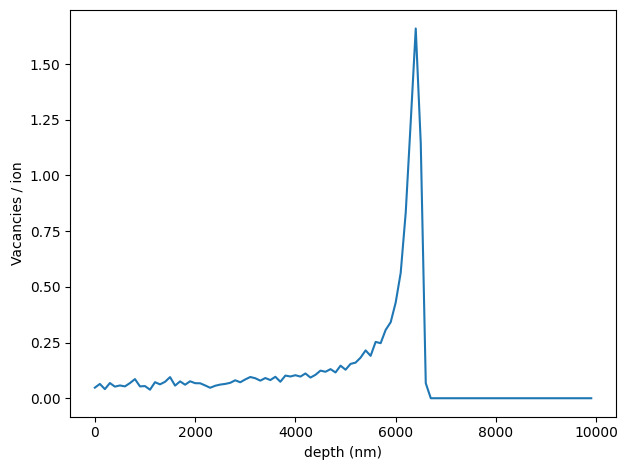

In [18]:
def list_h5(h5file: h5py.File) -> None:
    """
    Print a simple tree of the HDF5 file contents.

    Why this exists:
      - opentrim writes many datasets/groups and their names can change between versions.
      - Listing the structure makes it easy to discover what you can plot (dataset paths, shapes, dtypes).
    """
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"[D] {name}  shape={obj.shape}  dtype={obj.dtype}")
        elif isinstance(obj, h5py.Group):
            print(f"[G] {name}/")

    h5file.visititems(visitor)


def plot_dataset(arr: np.ndarray, *, title: str = "") -> None:
    """
    Plot a numeric dataset in a generic way.

    Why this exists:
      - In a notebook, you often just want a quick visualization without writing custom plotting code.
      - Handles common cases:
          * 1D arrays -> line plot
          * 2D arrays -> heatmap (imshow)
      - For other shapes, it prints a message rather than failing.
    """
    plt.figure()

    if arr.ndim == 1:
        plt.plot(arr)
        plt.xlabel("index")
        plt.ylabel("value")

    elif arr.ndim == 2:
        plt.imshow(arr, aspect="auto", origin="lower")
        plt.colorbar(label="value")
        plt.xlabel("x index")
        plt.ylabel("y index")

    else:
        plt.text(0.5, 0.5, f"Can't auto-plot shape {arr.shape}", ha="center", va="center")
        plt.axis("off")

    plt.title(title or f"shape={arr.shape}")
    plt.tight_layout()
    plt.show()


def plot_all_1d_numeric(h5file: h5py.File, *, max_plots: int = 12) -> None:
    """
    Plot up to `max_plots` 1D numeric datasets found anywhere in the file.

    Why this exists:
      - It's a fast way to "see something" after a run, without knowing the file structure beforehand.
      - It only plots 1D datasets because:
          * they're usually meaningful curves
          * they're cheap to render
          * it avoids accidentally plotting huge multidimensional tensors
    """
    plotted = 0

    def visitor(name, obj):
        nonlocal plotted
        if plotted >= max_plots:
            return

        if (
            isinstance(obj, h5py.Dataset)
            and obj.dtype.kind in ("i", "u", "f")   # integer/unsigned/float
            and obj.ndim == 1
            and obj.size > 0
        ):
            arr = np.asarray(obj[...])
            plot_dataset(arr, title=name)
            plotted += 1

    h5file.visititems(visitor)

    if plotted == 0:
        print("No 1D numeric datasets found to plot.")
    else:
        print(f"Plotted {plotted} dataset(s).")

# --- Run opentrim in an isolated temp directory, then read+plot the result ---

# Run with autofix: this will retry and remove unsupported keys until opentrim succeeds.
final_h5_path = run_opentrim_with_autofix(Config, exe=exe, out_base="result", seed="42")

print("\nOpening:", final_h5_path)

with h5py.File(final_h5_path, "r") as f:
    # Read datasets
    X = np.asarray(f["/target/grid/X"][...])  # shape (101,)
    Vacancies = np.asarray(f["/tally/damage_events/Vacancies"][...])  # shape (2,100,1,1)

    # Build x/y as requested
    x = X[0:100]                       # X(0:1:99) -> first 100 points
    y = Vacancies[1, 0:100, 0, 0]      # Vacancies[1,0:1:99,0,0]

    # Plot
    plt.figure()
    plt.plot(x, y)
    plt.xlabel("depth (nm)")
    plt.ylabel("Vacancies / ion")
    plt.tight_layout()
    plt.show()